# EDA Notebook

This notebook contains exploratory data analysis for the online shoppers intention dataset.

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio


In [4]:
df = pd.read_csv('/Users/nalinguest/Desktop/Agentik Project/data/online_shoppers_intention.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### Null Value check

In [5]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [7]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

### Categorical features


In [ ]:
categorical_cols = ["OperatingSystems", "Browser", "Region", "TrafficType", 
                    "Month", "VisitorType"]

df[categorical_cols] = df[categorical_cols].astype("category")


### Check for duplicates

In [8]:
df.duplicated().sum()

np.int64(125)

### Class distribution

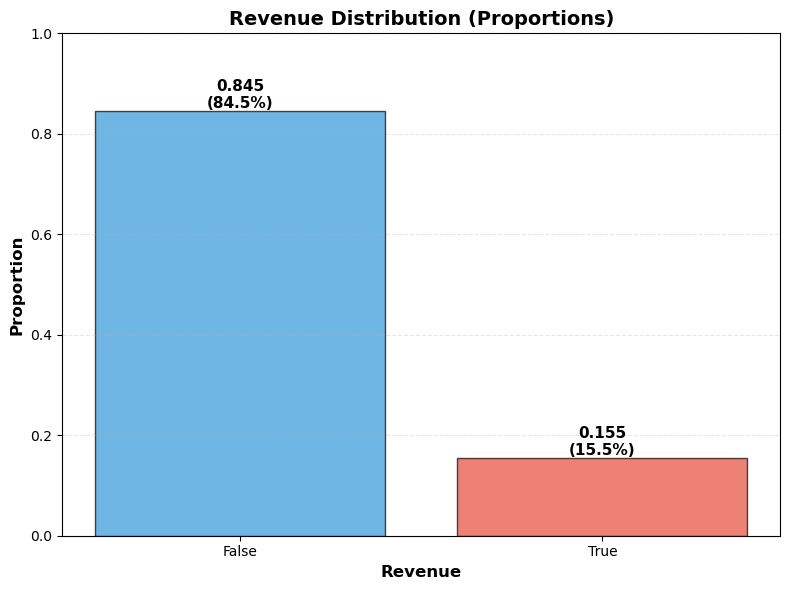

Revenue Distribution Summary:
False (No Purchase): 10,422 (84.53%)
True (Purchase):     1,908 (15.47%)
Total:               12,330

Ratio (False:True): 10422:1908 ≈ 5.46:1


In [15]:


# Chart showing the distribution of the target variable (Revenue) with proportions

# Get proportions
revenue_counts = df["Revenue"].value_counts()
revenue_props = df["Revenue"].value_counts(normalize=True)

# Create a single figure for proportions
fig, ax = plt.subplots(figsize=(8, 6))

# Bar chart with proportions
bars = ax.bar(revenue_props.index.astype(str), revenue_props.values, 
              color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')
ax.set_xlabel('Revenue', fontsize=12, fontweight='bold')
ax.set_ylabel('Proportion', fontsize=12, fontweight='bold')
ax.set_title('Revenue Distribution (Proportions)', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add proportion labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}\n({height*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Revenue Distribution Summary:")
print("=" * 50)
print(f"False (No Purchase): {revenue_counts[False]:,} ({revenue_props[False]*100:.2f}%)")
print(f"True (Purchase):     {revenue_counts[True]:,} ({revenue_props[True]*100:.2f}%)")
print(f"Total:               {len(df):,}")
print(f"\nRatio (False:True): {revenue_counts[False]}:{revenue_counts[True]} ≈ {revenue_counts[False]/revenue_counts[True]:.2f}:1")






In [ ]:
import matplotlib.pyplot as plt

# Revenue rate by Weekend
print("\nRevenue rate by Weekend:")
weekend_revenue = df.groupby("Weekend")["Revenue"].mean()
print(weekend_revenue)

fig, ax = plt.subplots()
weekend_revenue.plot(kind="bar", ax=ax, color=["#1abc9c", "#f39c12"], edgecolor='black')
ax.set_ylabel("Revenue Rate")
ax.set_xlabel("Weekend")
ax.set_title("Revenue Rate by Weekend")
ax.set_xticklabels(['Not Weekend', 'Weekend'], rotation=0)
for i, v in enumerate(weekend_revenue):
    ax.text(i, v + 0.01, f"{v:.2%}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# Revenue rate by VisitorType
print("\nRevenue rate by VisitorType:")
visitor_revenue = df.groupby("VisitorType")["Revenue"].mean()
print(visitor_revenue)

fig, ax = plt.subplots()
visitor_revenue.plot(kind="bar", ax=ax, color="#8e44ad", edgecolor='black')
ax.set_ylabel("Revenue Rate")
ax.set_xlabel("Visitor Type")
ax.set_title("Revenue Rate by Visitor Type")
for i, v in enumerate(visitor_revenue):
    ax.text(i, v + 0.01, f"{v:.2%}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# Revenue rate by Month
print("\nRevenue rate by Month:")
month_revenue = df.groupby("Month")["Revenue"].mean().sort_values()
print(month_revenue)

fig, ax = plt.subplots(figsize=(10,5))
month_revenue.plot(kind="bar", ax=ax, color="#3498db", edgecolor='black')
ax.set_ylabel("Revenue Rate")
ax.set_xlabel("Month")
ax.set_title("Revenue Rate by Month")
for i, v in enumerate(month_revenue):
    ax.text(i, v + 0.004, f"{v:.2%}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# Revenue rate by Browser
print("\nRevenue rate by Browser:")
browser_revenue = df.groupby("Browser")["Revenue"].mean()
print(browser_revenue)

fig, ax = plt.subplots()
browser_revenue.plot(kind="bar", ax=ax, color="#e67e22", edgecolor='black')
ax.set_ylabel("Revenue Rate")
ax.set_xlabel("Browser")
ax.set_title("Revenue Rate by Browser")
for i, v in enumerate(browser_revenue):
    ax.text(i, v + 0.01, f"{v:.2%}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# Revenue rate by Region
print("\nRevenue rate by Region:")
region_revenue = df.groupby("Region")["Revenue"].mean()
print(region_revenue)

fig, ax = plt.subplots(figsize=(8,5))
region_revenue.plot(kind="bar", ax=ax, color="#16a085", edgecolor='black')
ax.set_ylabel("Revenue Rate")
ax.set_xlabel("Region")
ax.set_title("Revenue Rate by Region")
for i, v in enumerate(region_revenue):
    ax.text(i, v + 0.01, f"{v:.2%}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### Bounce rates vs Exit Rates

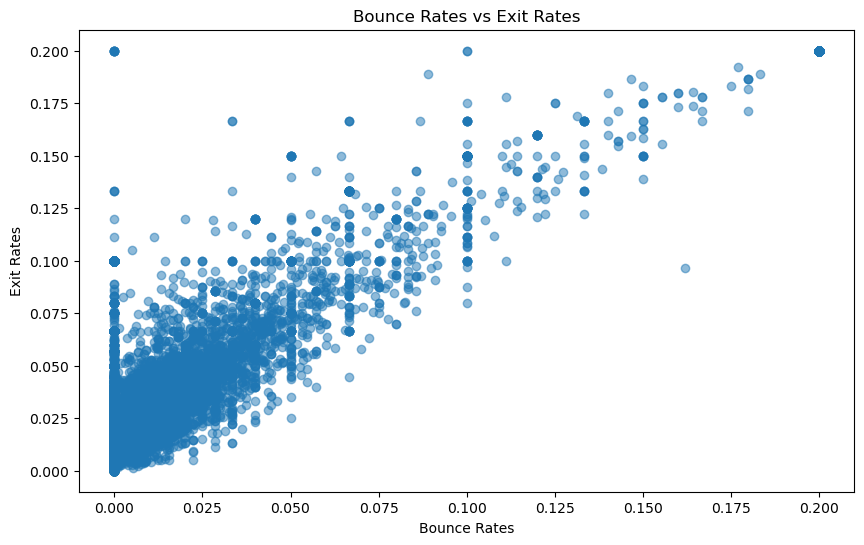

In [17]:
# create a scatter plot of bounce rates vs exit rates
plt.figure(figsize=(10, 6))
plt.scatter(df['BounceRates'], df['ExitRates'], alpha=0.5)
plt.xlabel('Bounce Rates')
plt.ylabel('Exit Rates')
plt.title('Bounce Rates vs Exit Rates')
plt.show()

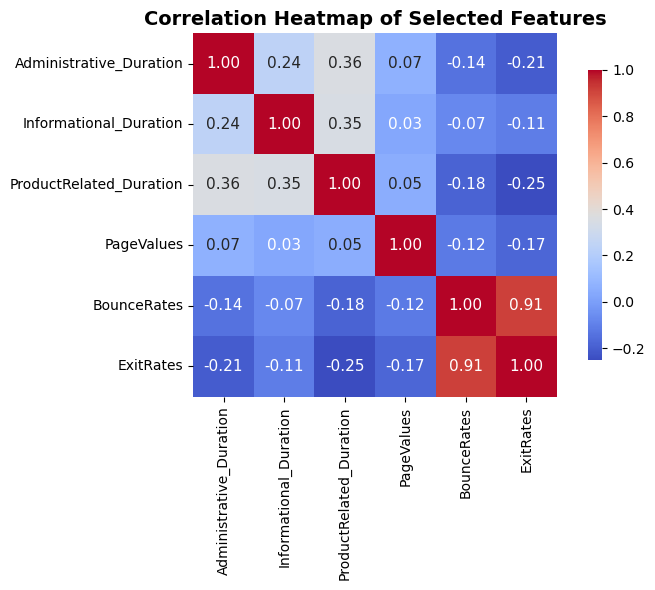

In [18]:
# Correlation matrix heatmap for selected features

import seaborn as sns

selected_features = [
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration',
    'PageValues',
    'BounceRates',
    'ExitRates'
]

corr_matrix = df[selected_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, 
            cbar_kws={"shrink": .8}, annot_kws={"size":11})
plt.title('Correlation Heatmap of Selected Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

